**FNO for 3D Seismic Traveltime Prediction**

@author : Yang Cui, Upsalla University

Factorized Eikonal:
            T = T0 + Tau

In [ ]:
import os, sys
sys.append("../quick_start")
from plotting import *

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import skfmm

from scipy.ndimage import gaussian_filter

In [2]:
# Parameters Setup

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

dx = dy = dz =10.0
num_train_src = 20  # num of random training sources
num_test_src = 5  # num of random testing sources

epochs = 200 # here I choose 50 to run on Google Colab, you need to increase to 200
batch_size = 1

lr = 5e-4
modes = 12  # fourier modes in FNO, change to 12 when you have GPU
width = 32 # Model width in latent layers, change to 16/32 if you have GPU

seed = 202605
torch.manual_seed(seed)
np.random.seed(seed)

cuda:0


In [3]:
# 3d geofwi model

def read_models(data_root, model_folders, index):
    image_file = os.path.join(data_root, model_folders[index], "image3d.bin")
    vp_file = os.path.join(data_root, model_folders[index], "vp3d.bin")
    rgt_file = os.path.join(data_root, model_folders[index], "rgt3d.bin")
    fault_file = os.path.join(data_root, model_folders[index], "fault3d.bin")
    shape = (96, 96, 96)
    image = np.memmap(image_file, dtype=np.float32, mode='r', shape=shape)
    vp = np.memmap(vp_file, dtype=np.float32, mode='r', shape=shape)
    rgt = np.memmap(rgt_file, dtype=np.float32, mode='r', shape=shape)
    fault = np.memmap(fault_file, dtype=np.float32, mode='r', shape=shape)
    salt = (rgt == 0).astype(np.float32)
    return image, vp, rgt, fault, salt


# plt sources distribution of training and testing data

def plot_source_distribution(vel, train_srcs, test_srcs, save_path=None):
    """
    Visualize training and test source locations
    inside the 3D velocity model.

    Green circles : training sources
    Red stars     : test sources
    """
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # transparent velocity slices
    nx, ny, nz = vel.shape
    # training sources
    train_srcs = np.array(train_srcs)
    ax.scatter(train_srcs[:, 0], train_srcs[:, 1], train_srcs[:, 2], c='lime', s=120, marker='o', edgecolors='black', linewidths=1.0, depthshade=False, label='Training Sources')
    # test sources
    test_srcs = np.array(test_srcs)
    ax.scatter(test_srcs[:, 0], test_srcs[:, 1], test_srcs[:, 2], c='red', s=300, marker='*', edgecolors='black', linewidths=1.2, depthshade=False, label='Test Sources')
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_xlabel("X", fontsize=12)
    ax.set_ylabel("Y", fontsize=12)
    ax.set_zlabel("Z", fontsize=12)
    ax.set_title("Sources Distribution", fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=12)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# vel model vsiualization

def plot_velocity_model(vel):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': '3d'})
    plot3d(vel.T, cmap='jet', frames=[45, 30, 60], ifnewfig=False, showf=False, close=False, ifinside=False)
    plt.title("Velocity Model", fontsize=18)
    plt.show()

for traveltime data generation

In [4]:
# Calculate T0
def analytical_T0(vel, src_idx, dx, dy, dz):
    nx, ny, nz = vel.shape
    si, sj, sk = src_idx
    v_src = vel[si, sj, sk]
    ii = np.arange(nx)[:, None, None]
    jj = np.arange(ny)[None, :, None]
    kk = np.arange(nz)[None, None, :]
    dist = np.sqrt(((ii - si) * dx) ** 2 + ((jj - sj) * dy) ** 2 + ((kk - sk) * dz) ** 2)
    T0 = dist / v_src
    return T0.astype(np.float32)


# Traveltime computing using skfmm
def compute_traveltime_fmm(vel, src_idx, dx, dy, dz):
    nx, ny, nz = vel.shape
    phi = -np.ones((nx, ny, nz), dtype=np.float64)
    phi[src_idx] = 1.0
    speed = vel.astype(np.float64)
    T = skfmm.travel_time(phi, speed=speed, dx=(dx, dy, dz))
    return T.astype(np.float32)


# data generation
def generate_dataset(vel, src_list, dx, dy, dz):
    T0_list = []
    T_list = []
    Tau_list = []
    for idx, src in enumerate(src_list):
        print(f"FMM Source {idx + 1}/{len(src_list)} @ {src}")
        t0 = time.time()
        T = compute_traveltime_fmm(vel, src, dx, dy, dz)
        T0 = analytical_T0(vel, src, dx, dy, dz)
        Tau = T - T0
        T0_list.append(T0)
        T_list.append(T)
        Tau_list.append(Tau)
        print(f"Finished in {time.time() - t0:.2f} sec")
    return T0_list, T_list, Tau_list

data splitting

In [5]:
# Data spliting
class SeismicDataset(Dataset):
    def __init__(self, vel, src_list, T0_list, Tau_list):
        self.samples = []
        nx, ny, nz = vel.shape
        vel = vel.astype(np.float32)
        v_mean = vel.mean()
        v_std = vel.std()
        vel_norm = (vel - v_mean) / (v_std + 1e-8)
        vel_norm = torch.tensor(vel_norm, dtype=torch.float32)
        for src, T0, Tau in zip(src_list, T0_list, Tau_list):
            src_map = np.zeros((nx, ny, nz), dtype=np.float32)
            src_map[src] = 1.0
            src_map = gaussian_filter(src_map, sigma=3)
            src_map = torch.tensor(src_map, dtype=torch.float32)
            T0 = torch.tensor(T0, dtype=torch.float32)
            Tau = torch.tensor(Tau, dtype=torch.float32)
            x = torch.stack([vel_norm, T0, src_map], dim=0)
            y = Tau.unsqueeze(0)
            self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

Build Fourier Neural Operators for Traveltime Simulation

In [6]:
# define the model
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, modes3):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3
        scale = 1 / (in_channels * out_channels)
        self.weights = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, modes3, dtype=torch.cfloat))

    def compl_mul3d(self, x, weights):
        return torch.einsum("bixyz,ioxyz->boxyz", x, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[-3, -2, -1])
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2, :self.modes3] = self.compl_mul3d(x_ft[:, :, :self.modes1, :self.modes2, :self.modes3], self.weights)
        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x


# FNO model
class FNO3d(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, modes=6, width=16, n_layers=4):
        super().__init__()
        self.fc0 = nn.Linear(in_ch, width)
        self.convs = nn.ModuleList([SpectralConv3d(width, width, modes, modes, modes) for _ in range(n_layers)])
        self.ws = nn.ModuleList([nn.Conv3d(width, width, 1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, out_ch)

    def forward(self, x):
        x = x.permute(0, 2, 3, 4, 1)
        x = self.fc0(x)
        x = x.permute(0, 4, 1, 2, 3)
        for conv, w in zip(self.convs, self.ws):
            x1 = conv(x)
            x2 = w(x)
            x = F.gelu(x1 + x2)
        x = x.permute(0, 2, 3, 4, 1)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        x = x.permute(0, 4, 1, 2, 3)
        return x

Training Loop

In [7]:
# define the training function
def train_fno(model, train_loader, val_loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=epochs // 3, gamma=0.5)
    loss_fn = nn.MSELoss()
    history = {"train": [], "val": []}

    for ep in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                val_loss += loss_fn(pred, yb).item()
        val_loss /= len(val_loader)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        print(f"Epoch {ep + 1:03d} | Train={train_loss:.6e} | Val={val_loss:.6e}")

    return history

Inference Loop

In [8]:
# Inference
def predict_traveltime(model, vel, src, dx, dy, dz, v_mean, v_std):
    nx, ny, nz = vel.shape
    T0 = analytical_T0(vel, src, dx, dy, dz)
    vel_norm = (vel - v_mean) / (v_std + 1e-8)
    src_map = np.zeros((nx, ny, nz), dtype=np.float32)
    src_map[src] = 1.0
    src_map = gaussian_filter(src_map, sigma=3)
    x = np.stack([vel_norm, T0, src_map], axis=0)[None]
    x = torch.tensor(x, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        Tau_pred = model(x)[0, 0]
    Tau_pred = Tau_pred.cpu().numpy()
    T_pred = T0 + Tau_pred
    return T0, T_pred, Tau_pred


# Plotting the results
def plot3d_results(vel, T_true, T_pred, src, save_path=None):
    err = np.abs(T_true - T_pred)
    fig, ax = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': '3d'}, constrained_layout=True)
    axes = ax.ravel()
    data_list = [vel, T_true, T_pred, err]
    titles = ["Velocity Model", "FMM Traveltime", "FNO Prediction", "Absolute Error"]
    cmaps = ['jet', 'jet', 'jet', 'hot_r']

    for axx, data, title, cmap_name in zip(axes, data_list, titles, cmaps):
        axx.set_title(title, fontsize=14, fontweight='bold')
        plt.sca(axx)
        plot3d(data.T, cmap=cmap_name, frames=[45, 30, 60], ifnewfig=False, showf=False, close=False, ifinside=False)
        axx.scatter(src[0], src[1], src[2], c='white', s=100, marker='*')

    plt.suptitle(f"Source Location: {src}", fontsize=18, fontweight='bold')
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #plt.close()

Main Loop


Loading REAL GeoFWI3D model...
Velocity shape : (96, 96, 96)
Velocity min   : 1839.68
Velocity max   : 4371.21


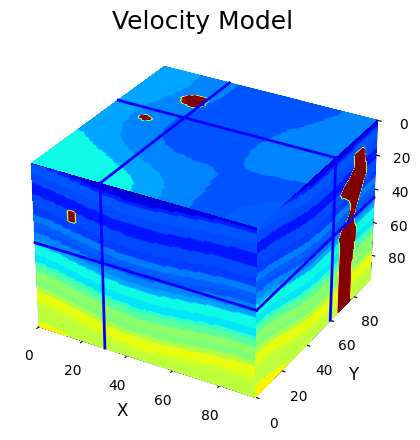

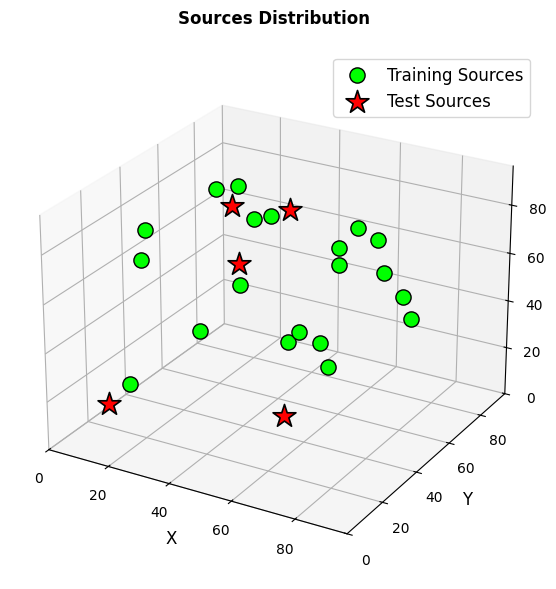


Generating Training Data...
FMM Source 1/20 @ (35, 55, 77)
Finished in 0.61 sec
FMM Source 2/20 @ (71, 66, 60)
Finished in 0.61 sec
FMM Source 3/20 @ (70, 52, 85)
Finished in 0.60 sec
FMM Source 4/20 @ (15, 80, 73)
Finished in 0.59 sec
FMM Source 5/20 @ (16, 25, 70)
Finished in 0.60 sec
FMM Source 6/20 @ (63, 54, 74)
Finished in 0.61 sec
FMM Source 7/20 @ (29, 75, 67)
Finished in 0.61 sec
FMM Source 8/20 @ (29, 57, 47)
Finished in 0.61 sec
FMM Source 9/20 @ (40, 17, 53)
Finished in 0.60 sec
FMM Source 10/20 @ (65, 40, 43)
Finished in 0.61 sec
FMM Source 11/20 @ (79, 68, 42)
Finished in 0.60 sec
FMM Source 12/20 @ (33, 78, 12)
Finished in 0.60 sec
FMM Source 13/20 @ (15, 29, 80)
Finished in 0.60 sec
FMM Source 14/20 @ (55, 63, 17)
Finished in 0.61 sec
FMM Source 15/20 @ (14, 21, 20)
Finished in 0.61 sec
FMM Source 16/20 @ (72, 16, 63)
Finished in 0.60 sec
FMM Source 17/20 @ (66, 72, 69)
Finished in 0.60 sec
FMM Source 18/20 @ (70, 80, 42)
Finished in 0.60 sec
FMM Source 19/20 @ (14, 69

In [ ]:
#Main loop

os.makedirs("results", exist_ok=True)

#load vel model
print("\nLoading REAL GeoFWI3D model...")
data_root = '../allmodels'
model_folders = [f'model_{i:04d}' for i in range(1000, 1001)]
image, vel, rgt, fault, salt = read_models(data_root, model_folders, 0)
vel = np.array(vel)
NX, NY, NZ = vel.shape
print(f"Velocity shape : {vel.shape}")
print(f"Velocity min   : {vel.min():.2f}")
print(f"Velocity max   : {vel.max():.2f}")
plot_velocity_model(vel)

# generate random sources
margin = 10
all_srcs = []
while len(all_srcs) < (num_train_src + num_test_src):
    candidate = (np.random.randint(margin, NX - margin), np.random.randint(margin, NY - margin), np.random.randint(margin, NZ - margin))
    if candidate not in all_srcs:
        all_srcs.append(candidate)
train_srcs = all_srcs[:num_train_src]
test_srcs = all_srcs[num_train_src:]
plot_source_distribution(vel, train_srcs, test_srcs, save_path="results/source_distribution.png")

# training data generation
print("\nGenerating Training Data...")
T0_tr, T_tr, Tau_tr = generate_dataset(vel, train_srcs, dx, dy, dz)
print("\nGenerating Test Data...")
T0_te, T_te, Tau_te = generate_dataset(vel, test_srcs, dx, dy, dz)

# prepare dataset for fno
dataset = SeismicDataset(vel, train_srcs, T0_tr, Tau_tr)
n_val = max(1, len(dataset) // 5)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("\nDataset:")
print(f"Train samples : {n_train}")
print(f"Val samples   : {n_val}")

print("\nBuilding FNO model...")
model = FNO3d(in_ch=3, out_ch=1, modes=modes, width=width).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

# training loop
print("\nTraining FNO...")
history = train_fno(model, train_loader, val_loader, epochs, lr)

# save the checkpoint
torch.save(model.state_dict(), "results/fno3d_seismic.pth")




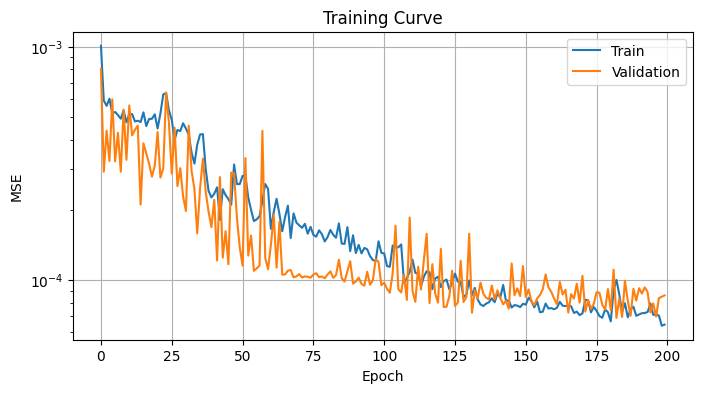

In [10]:
# plot the loss courves
plt.figure(figsize=(8, 4))
plt.semilogy(history["train"], label="Train")
plt.semilogy(history["val"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Curve")
plt.grid(True)
plt.legend()
plt.savefig("results/training_curve.png", dpi=300, bbox_inches='tight')


In [11]:
# inference
print("\nPrediction on test sources...")
v_mean = vel.mean()
v_std = vel.std()

MAE_list = []
RMSE_list = []

for i, (src, T_true) in enumerate(zip(test_srcs, T_te)):
    print(f"\nTest Source {i + 1}: {src}")
    T0, T_pred, Tau_pred = predict_traveltime(model, vel, src, dx, dy, dz, v_mean, v_std)
    mae = np.mean(np.abs(T_pred - T_true))
    rmse = np.sqrt(np.mean((T_pred - T_true) ** 2))
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    MAE_list.append(mae)
    RMSE_list.append(rmse)
    # plot3d_results(vel, T_true, T_pred, src, save_path=f"results/test_source_{i + 1}.png")

print("\nDone!")


Prediction on test sources...

Test Source 1: (20, 68, 72)
MAE  = 0.003144
RMSE = 0.004356

Test Source 2: (36, 74, 72)
MAE  = 0.003292
RMSE = 0.004296

Test Source 3: (61, 27, 19)
MAE  = 0.014115
RMSE = 0.019690

Test Source 4: (14, 10, 18)
MAE  = 0.005116
RMSE = 0.007522

Test Source 5: (54, 15, 85)
MAE  = 0.008513
RMSE = 0.013563

Done!


In [12]:
# metrics
MAE = np.mean(MAE_list)
RMSE = np.mean(RMSE_list)
print(f"MAE  = {MAE:.6f}")
print(f"RMSE = {RMSE:.6f}")

MAE  = 0.006836
RMSE = 0.009885


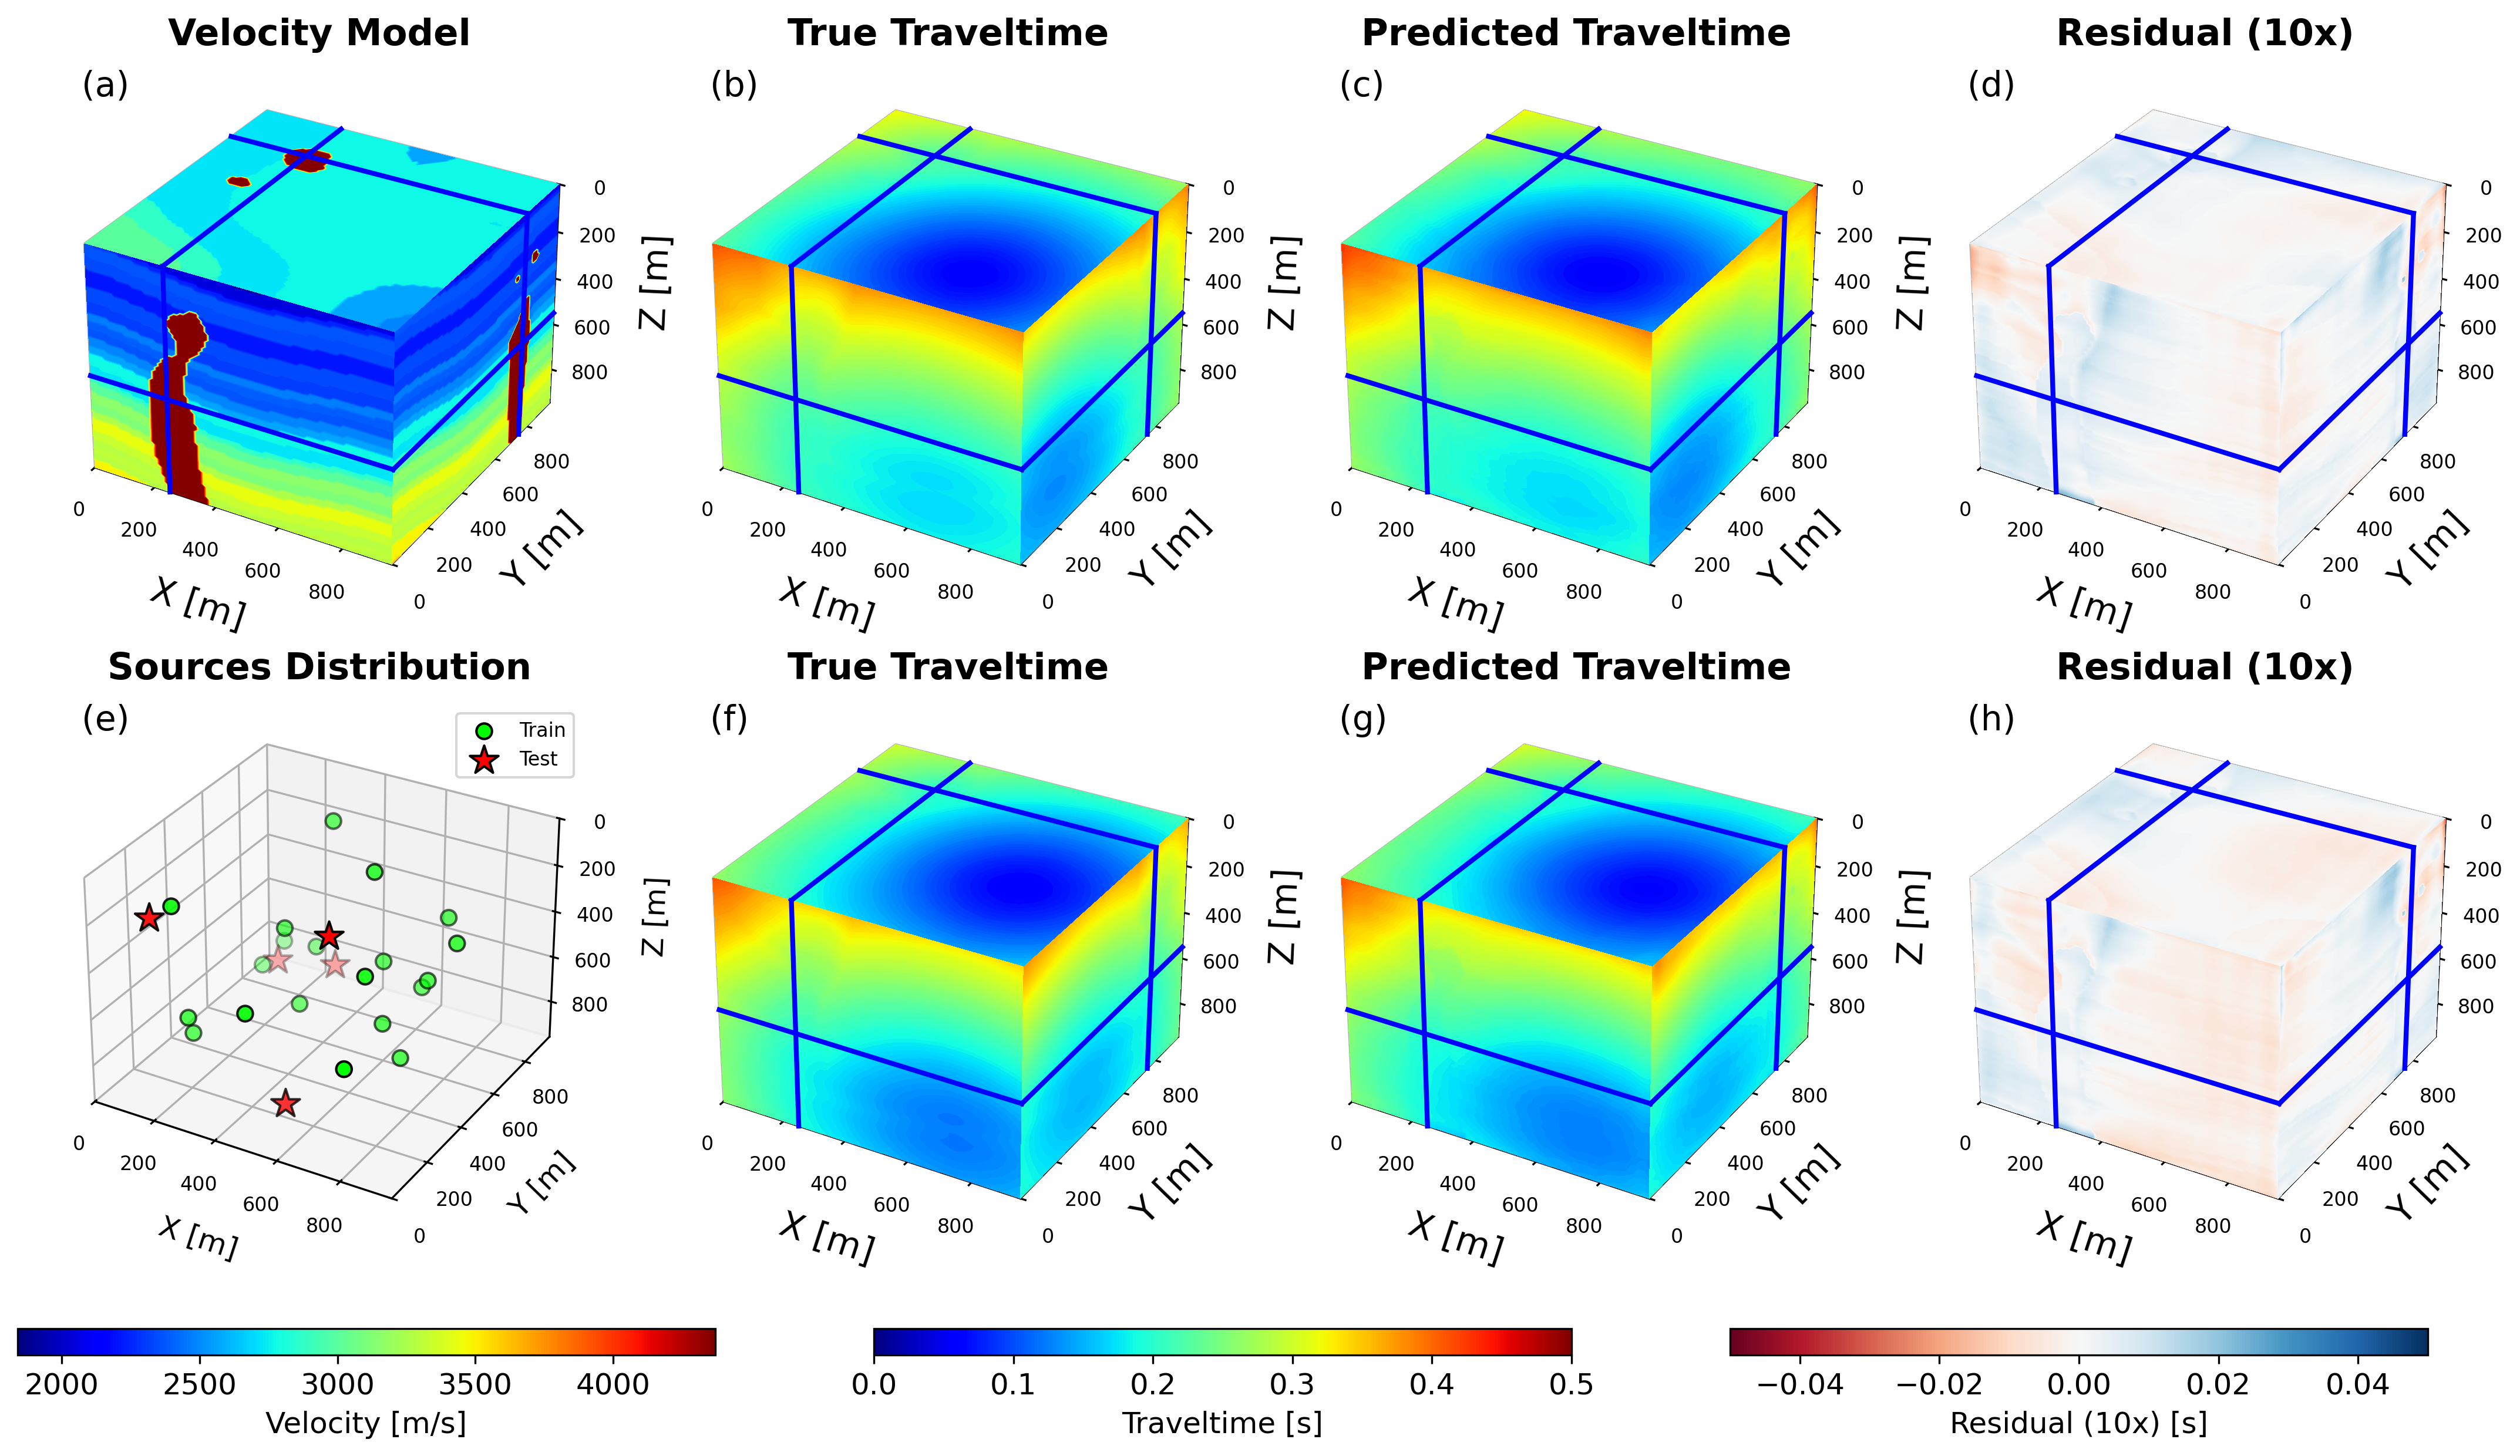

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import string

# 1. Global typography
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'figure.dpi': 300
})

frames = [55, 25, 75]

v_mean, v_std = vel.mean(), vel.std()
src1, T_true1 = test_srcs[0], T_te[0]
_, T_pred1, _ = predict_traveltime(model, vel, src1, dx, dy, dz, v_mean, v_std)
err1 = (T_true1 - T_pred1)

src2, T_true2 = test_srcs[1], T_te[1]
_, T_pred2, _ = predict_traveltime(model, vel, src2, dx, dy, dz, v_mean, v_std)
err2 = (T_true2 - T_pred2)

# 2. Setup Figure (2 rows, 4 columns)
# Removed constrained_layout to manually control colorbar axes
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 10), 
    subplot_kw={"projection": "3d"}
)
fig.subplots_adjust(bottom=0.22, hspace=0.2, wspace=0.1)

axes_flat = axes.flatten()

plot_items = [
    (vel, "Velocity Model", 'jet', src1),
    (T_true1, "True Traveltime", 'jet', src1),
    (T_pred1, "Predicted Traveltime", 'jet', src1),
    (err1, "Residual (10x)", 'RdBu', src1),
    ("source_dist", "Sources Distribution", None, None),
    (T_true2, "True Traveltime", 'jet', src2),
    (T_pred2, "Predicted Traveltime", 'jet', src2),
    (err2, "Residual (10x)", 'RdBu', src2)
]

alphabet = string.ascii_lowercase
letter_idx = 0

for idx, item in enumerate(plot_items):
    ax = axes_flat[idx]
    data, title, cmap_name, src = item
    plt.sca(ax)
    ax.set_title(title, pad=10)
    
    is_source_plot = isinstance(data, str) and data == "source_dist"

    if is_source_plot:
        nx, ny, nz = vel.shape
        tr_coords = np.array(train_srcs) * np.array([dx, dy, dz])
        ax.scatter(tr_coords[:, 0], tr_coords[:, 1], tr_coords[:, 2],
                   c='lime', s=40, marker='o', edgecolors='black', label='Train')
        te_coords = np.array(test_srcs) * np.array([dx, dy, dz])
        ax.scatter(te_coords[:, 0], te_coords[:, 1], te_coords[:, 2],
                   c='red', s=150, marker='*', edgecolors='black', label='Test')
        ax.set_xlim(0, nx * dx); ax.set_ylim(0, ny * dy); ax.set_zlim(nz * dz, 0)
        ax.legend(loc='upper right', fontsize=8)
        ax.view_init(elev=30, azim=-60)
    else:
        # Standard Plotting logic
        if idx == 0:
            plot3d(data.T, cmap=cmap_name, frames=frames, dx=dx, dy=dy, dz=dz,
                   ifnewfig=False, showf=False, close=False, ifinside=False)
        elif idx in [3, 7]:
            plot3d(data.T, cmap=cmap_name, frames=frames, dx=dx, dy=dy, dz=dz,
                   ifnewfig=False, showf=False, close=False, ifinside=False,
                   vmin=-0.05, vmax=0.05)
        else:
            plot3d(data.T, cmap=cmap_name, frames=frames, dx=dx, dy=dy, dz=dz,
                   ifnewfig=False, showf=False, close=False, ifinside=False,
                   vmin=0, vmax=0.5)

        sx, sy, sz = src[0] * dx, src[1] * dy, src[2] * dz
        ax.scatter(sx, sy, sz, c="white", s=150, marker="*", edgecolors="black")

    ax.tick_params(labelsize=8, pad=2)
    ax.set_xlabel('X [m]', labelpad=5); ax.set_ylabel('Y [m]', labelpad=5); ax.set_zlabel('Z [m]', labelpad=5)
    ax.text2D(0.05, 0.95, f'({alphabet[letter_idx]})', transform=ax.transAxes, fontsize=14, zorder=10)
    letter_idx += 1

# 3. Add 3 Horizontal Colorbars at the Bottom
# Define the color scales to match your plot limits
norm_vel = mcolors.Normalize(vmin=vel.min(), vmax=vel.max())
norm_tt  = mcolors.Normalize(vmin=0, vmax=0.5)
norm_res = mcolors.Normalize(vmin=-0.05, vmax=0.05)

# Positions: [left, bottom, width, height]
cbar_width = 0.22
cbar_bottom = 0.15
cbar_height = 0.015

# Bar 1: Velocity
cb_ax1 = fig.add_axes([0.12, cbar_bottom, cbar_width, cbar_height])
cb1 = fig.colorbar(cm.ScalarMappable(norm=norm_vel, cmap='jet'), cax=cb_ax1, orientation='horizontal')
cb1.set_label('Velocity [m/s]')

# Bar 2: Traveltime
cb_ax2 = fig.add_axes([0.39, cbar_bottom, cbar_width, cbar_height])
cb2 = fig.colorbar(cm.ScalarMappable(norm=norm_tt, cmap='jet'), cax=cb_ax2, orientation='horizontal')
cb2.set_label('Traveltime [s]')

# Bar 3: Residual
cb_ax3 = fig.add_axes([0.66, cbar_bottom, cbar_width, cbar_height])
cb3 = fig.colorbar(cm.ScalarMappable(norm=norm_res, cmap='RdBu'), cax=cb_ax3, orientation='horizontal')
cb3.set_label('Residual (10x) [s]')

for ax in axes.flatten():
    ax.set_rasterized(True)

# plt.savefig("fno-tt.pdf", dpi=300, bbox_inches='tight')
plt.show()